In [1]:
import sys
sys.path.append('..')

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger
import numpy as np
from PIL import Image
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

torch.manual_seed(42)
np.random.seed(42)
pl.seed_everything(42)

W0606 13:53:28.171000 16880 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42


42

## Загрузка данных

Создаём даталоадеры для обучения и валидации.

In [3]:
from src.augmentations import get_train_augmentation, get_val_augmentation
from src.dataset import CamVidDataset
import config

360 x 480 пикселей

In [4]:
data_dir = config.DATA_DIR
img_size = config.IMG_SIZE
print(img_size)

train_transform = get_train_augmentation(img_size=img_size)
val_transform = get_val_augmentation(img_size=img_size)

train_dataset = CamVidDataset(
    data_dir=data_dir,
    split='train',
    img_size=img_size,
    transform=train_transform
)

val_dataset = CamVidDataset(
    data_dir=data_dir,
    split='val',
    img_size=img_size,
    transform=val_transform
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

batch_size = config.BATCH_SIZE
num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=False
)
print(batch_size)

(360, 480)
Loaded 367 samples from train split
Loaded 101 samples from val split
Train samples: 367
Val samples: 101
8


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Визуализация данных

Проверяем загрузку данных и визуализируем примеры изображений и масок.


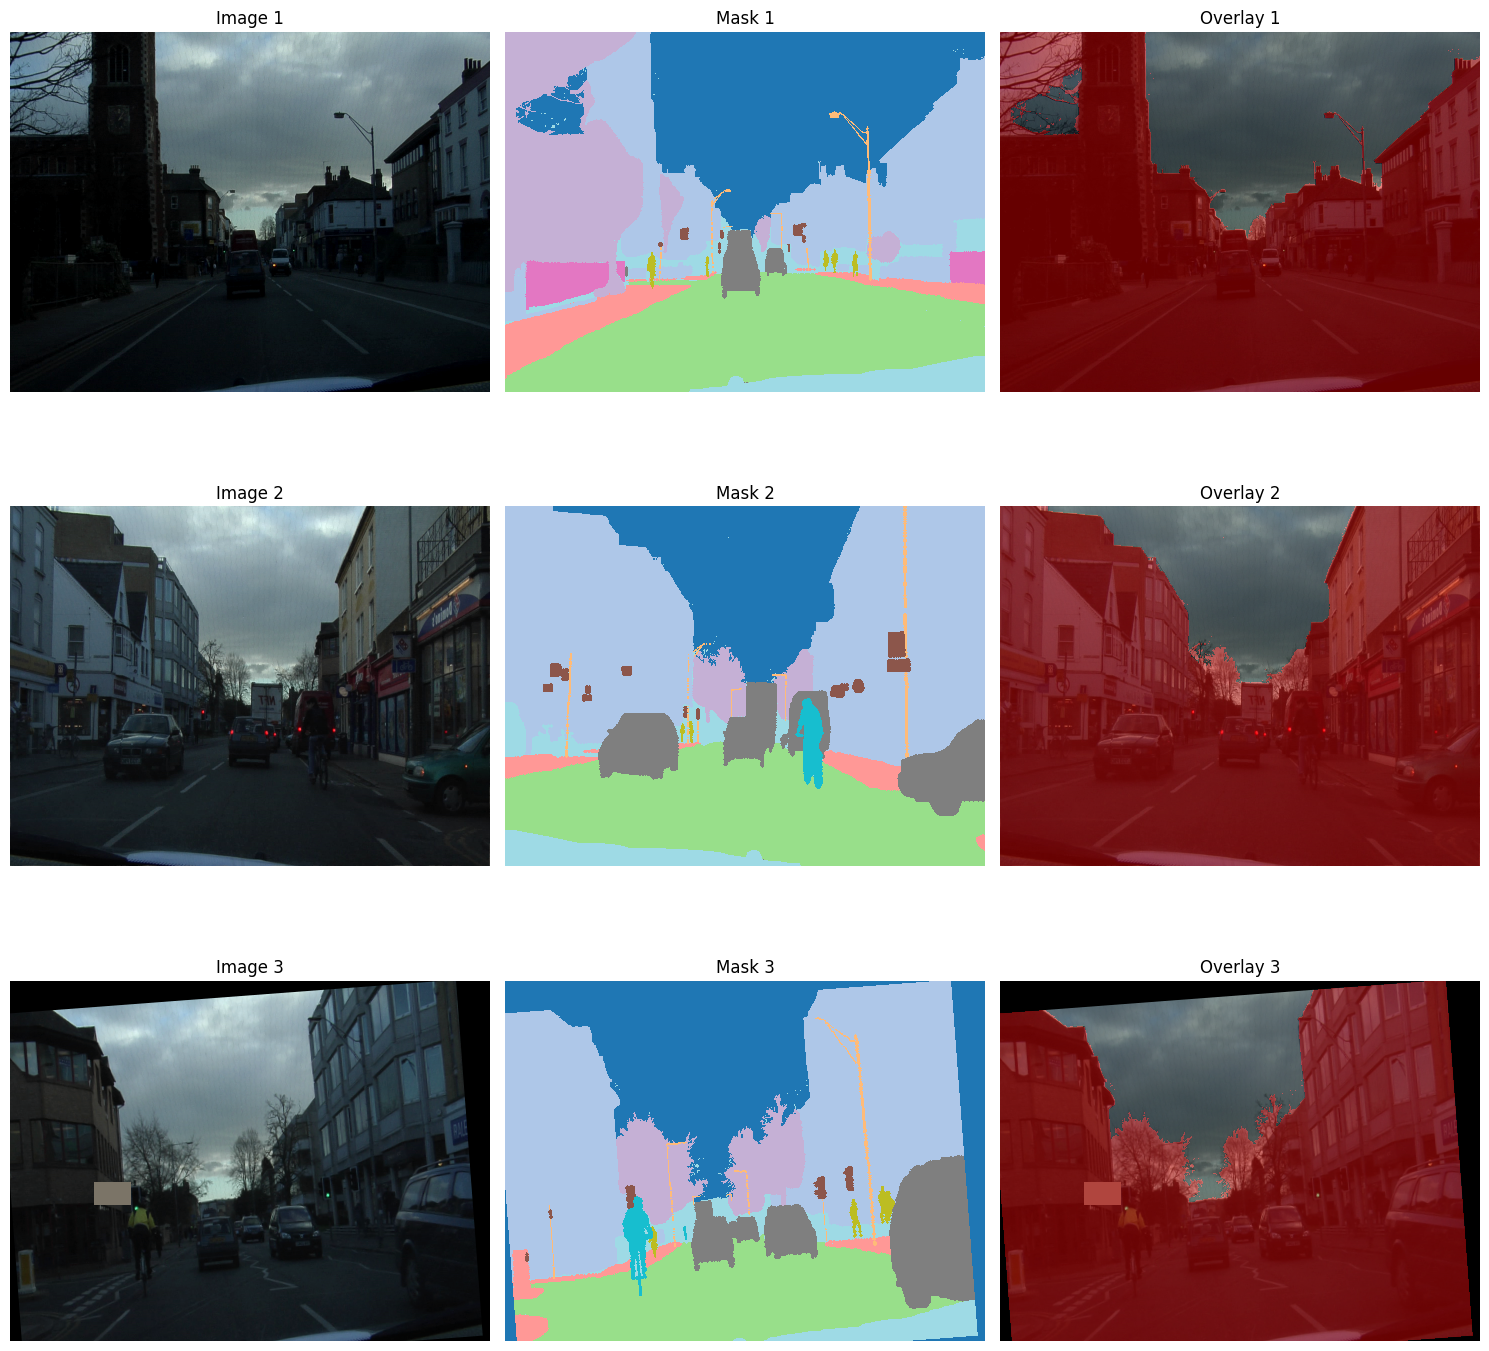

Image shape: torch.Size([3, 360, 480])
Mask shape: torch.Size([360, 480])
Mask unique values: tensor([ 0,  1,  2,  3,  4,  5,  6,  8,  9, 10, 11])


In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i in range(3):
    image, mask = train_dataset[(i+2)*15]

    img_np = image.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)
    
    mask_np = mask.numpy()
    
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f'Image {i+1}')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(mask_np, cmap='tab20', vmin=0, vmax=11)
    axes[i, 1].set_title(f'Mask {i+1}')
    axes[i, 1].axis('off')
    
    overlay = img_np.copy()
    mask_colored = np.zeros_like(img_np)
    mask_colored[mask_np > 0] = [1, 0, 0]
    overlay = overlay * 0.6 + mask_colored * 0.4
    
    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title(f'Overlay {i+1}')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"Image shape: {image.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Mask unique values: {torch.unique(mask)}")


### Взвешивание классов

In [6]:
from config import MASK_DIR
from src.utils import cumpute_classes_weights

weights = cumpute_classes_weights(MASK_DIR)
for weight in weights:
    print(weight)
# после рассчета веса будут перенесены в config для дальнейшего использовагния в модуле лайтниг

0.3991
0.4471
8.8448
0.3252
2.241
0.5429
4.9346
14.2235
1.3435
19.9878
25.5686
1.4829


## Инициализация модели

Создаём модель UNet и Lightning модуль для обучения.

In [7]:
from src.lightning_module import UNetModule
from src.model import model
from config import LEARNING_RATE

unet_module = UNetModule(
    model=model,
    learning_rate=LEARNING_RATE
)

sample_input = torch.randn(1, 3, 360, 480)
with torch.no_grad():
    sample_output = unet_module(sample_input)

print(f"Input shape: {sample_input.shape}")
print(f"Output shape: {sample_output.shape}")
print(f"Model parameters: {sum(p.numel() for p in unet_module.parameters()):,}")


Input shape: torch.Size([1, 3, 360, 480])
Output shape: torch.Size([1, 12, 360, 480])
Model parameters: 13,160,628


## Обучение модели

Настраиваем callbacks и запускаем обучение с использованием PyTorch Lightning.

In [8]:
import torch
torch.cuda.empty_cache()

In [9]:
from config import MAX_EPOCHS

checkpoint_callback = ModelCheckpoint(
    dirpath='../models/checkpoints/',
    monitor='val_iou',
    mode='max',
    save_top_k=1,
    filename='unet-{epoch:02d}-{val_iou:.4f}',
    save_last=True
)

early_stop_callback = EarlyStopping(
    monitor='val_iou',
    mode='max',
    patience=30,
    verbose=True
)

logger = TensorBoardLogger(
    save_dir='logs/lightning_logs/',
    name='unet_segmentation'
)

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    callbacks=[checkpoint_callback, early_stop_callback],
    logger=logger,
    log_every_n_steps=10,
    val_check_interval=0.5,
    num_sanity_val_steps=0,
    precision='16-mixed'
)


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [16]:

trainer.fit(unet_module, train_loader, val_loader)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion │ WeightedFocalLoss │      0 │ train │     0 │
│ 1 │ model     │ Unet              │ 13.2 M │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 13.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.2 M                                                                                               
Total estimated model params size (MB): 52.643                                                                     
Modules in train mode: 475                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_iou improved. New best score: 0.556
Metric val_iou improved by 0.006 >= min_delta = 0.0. New best score: 0.562
Metric val_iou improved by 0.013 >= min_delta = 0.0. New best score: 0.575
Metric val_iou improved by 0.003 >= min_delta = 0.0. New best score: 0.578
Metric val_iou improved by 0.010 >= min_delta = 0.0. New best score: 0.587
Metric val_iou improved by 0.011 >= min_delta = 0.0. New best score: 0.599
Metric val_iou improved by 0.005 >= min_delta = 0.0. New best score: 0.603
Metric val_iou improved by 0.009 >= min_delta = 0.0. New best score: 0.612
Metric val_iou improved by 0.003 >= min_delta = 0.0. New best score: 0.615
Metric val_iou improved by 0.003 >= min_delta = 0.0. New best score: 0.618
Metric val_iou improved by 0.002 >= min_delta = 0.0. New best score: 0.620
Metric val_iou improved by 0.003 >= min_delta = 0.0. New best score: 0.623
Metric val_iou improved by 0.006 >= min_delta = 0.0. New best score: 0.629
Metric val_iou improved by 0.003 >= min_delta = 0.0. 

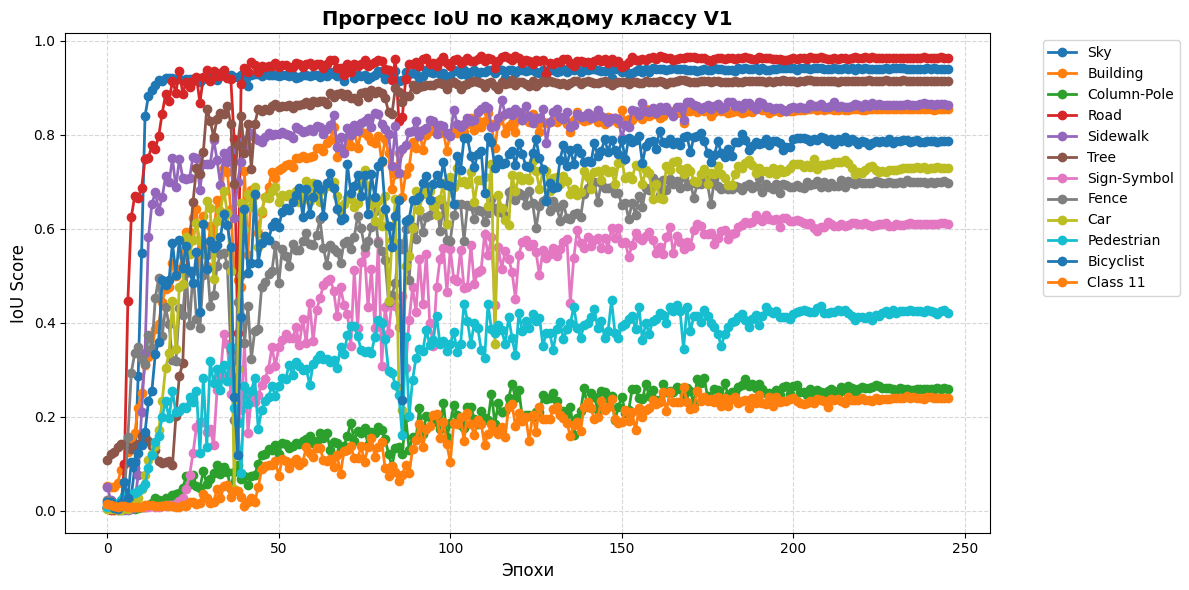

In [17]:
import matplotlib.pyplot as plt

history = unet_module.iou_history

class_names = ["Sky", "Building", "Column-Pole", "Road", "Sidewalk", "Tree", "Sign-Symbol", "Fence", "Car", "Pedestrian", "Bicyclist"]

plt.figure(figsize=(12, 6))

for cls_idx, iou_values in history.items():
    epochs = range(len(iou_values))
    label_name = class_names[cls_idx] if cls_idx < len(class_names) else f"Class {cls_idx}"
    plt.plot(epochs, iou_values, marker='o', label=label_name, linewidth=2)

plt.title("Прогресс IoU по каждому классу V1", fontsize=14, fontweight='bold')
plt.xlabel("Эпохи", fontsize=12)
plt.ylabel("IoU Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Финальное mIoU : 0.692

Уже после окончания обучения, я поняла, что не отключила в функции потерь и в метрике класс Void, поэтому усредненная метрика искусственно занижена.

In [10]:
best_ckpt = "../models/checkpoints/unet-epoch=93-val_iou=0.6919.ckpt"
from src.model import model
import ttach as tta
from src.lightning_module import UNetModule
from src.utils import compute_iou
from config import NUM_CLASSES

model_to_val = UNetModule.load_from_checkpoint(checkpoint_path=best_ckpt, model=model)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_to_val = model_to_val.to(device)
model_to_val.eval()
tta_model = tta.SegmentationTTAWrapper(
    model_to_val.eval(), 
    tta.Compose([tta.HorizontalFlip()]), 
    merge_mode='mean'
)


val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)
total_iou = 0
num_photos = 0
total_iou_per_class = torch.tensor([0.0 for _ in range(11)])
total_list_iou_per_class = []

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="TTA Validation"):
        images = images.to(device)
        masks = masks.to(device)
        
        logits = tta_model(images)
        preds = torch.argmax(logits, dim=1)
        
        mean_iou, ious = compute_iou(preds, masks, NUM_CLASSES)
        total_iou += mean_iou * len(images)
        num_photos += len(images)
        total_iou_per_class += ious
        total_list_iou_per_class.append(ious)
        


TTA Validation: 100%|██████████| 26/26 [00:02<00:00,  9.12it/s]


In [11]:
print(f'TTA mIoU: {round((total_iou/num_photos).item(), 3)}', '\n')

mean_iou_per_classes = [round(el, 3) for el in (total_iou_per_class/np.ceil(num_photos/val_loader.batch_size)).tolist()]

print(f'TTA IoU per class: {mean_iou_per_classes}', '\n')


TTA mIoU: 0.736 

TTA IoU per class: [0.941, 0.856, 0.272, 0.963, 0.86, 0.916, 0.627, 0.705, 0.742, 0.416, 0.794] 



<BarContainer object of 11 artists>

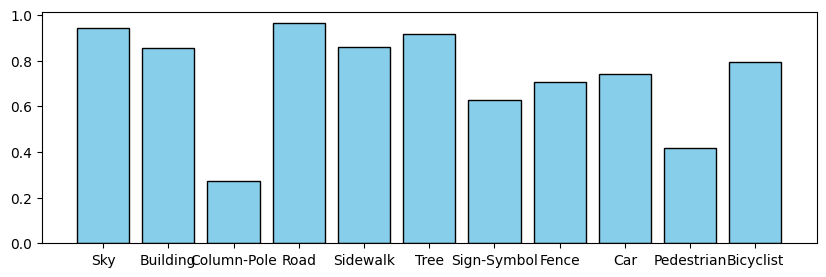

In [12]:
import matplotlib.pyplot as plt

CAMVID_CLASSES = [
    "Sky",
    "Building",
    "Column-Pole",
    "Road",
    "Sidewalk",
    "Tree",
    "Sign-Symbol",
    "Fence",
    "Car",
    "Pedestrian",
    "Bicyclist"
]
plt.figure(figsize=(10, 3))

plt.bar(CAMVID_CLASSES, mean_iou_per_classes, color="skyblue", edgecolor="black")

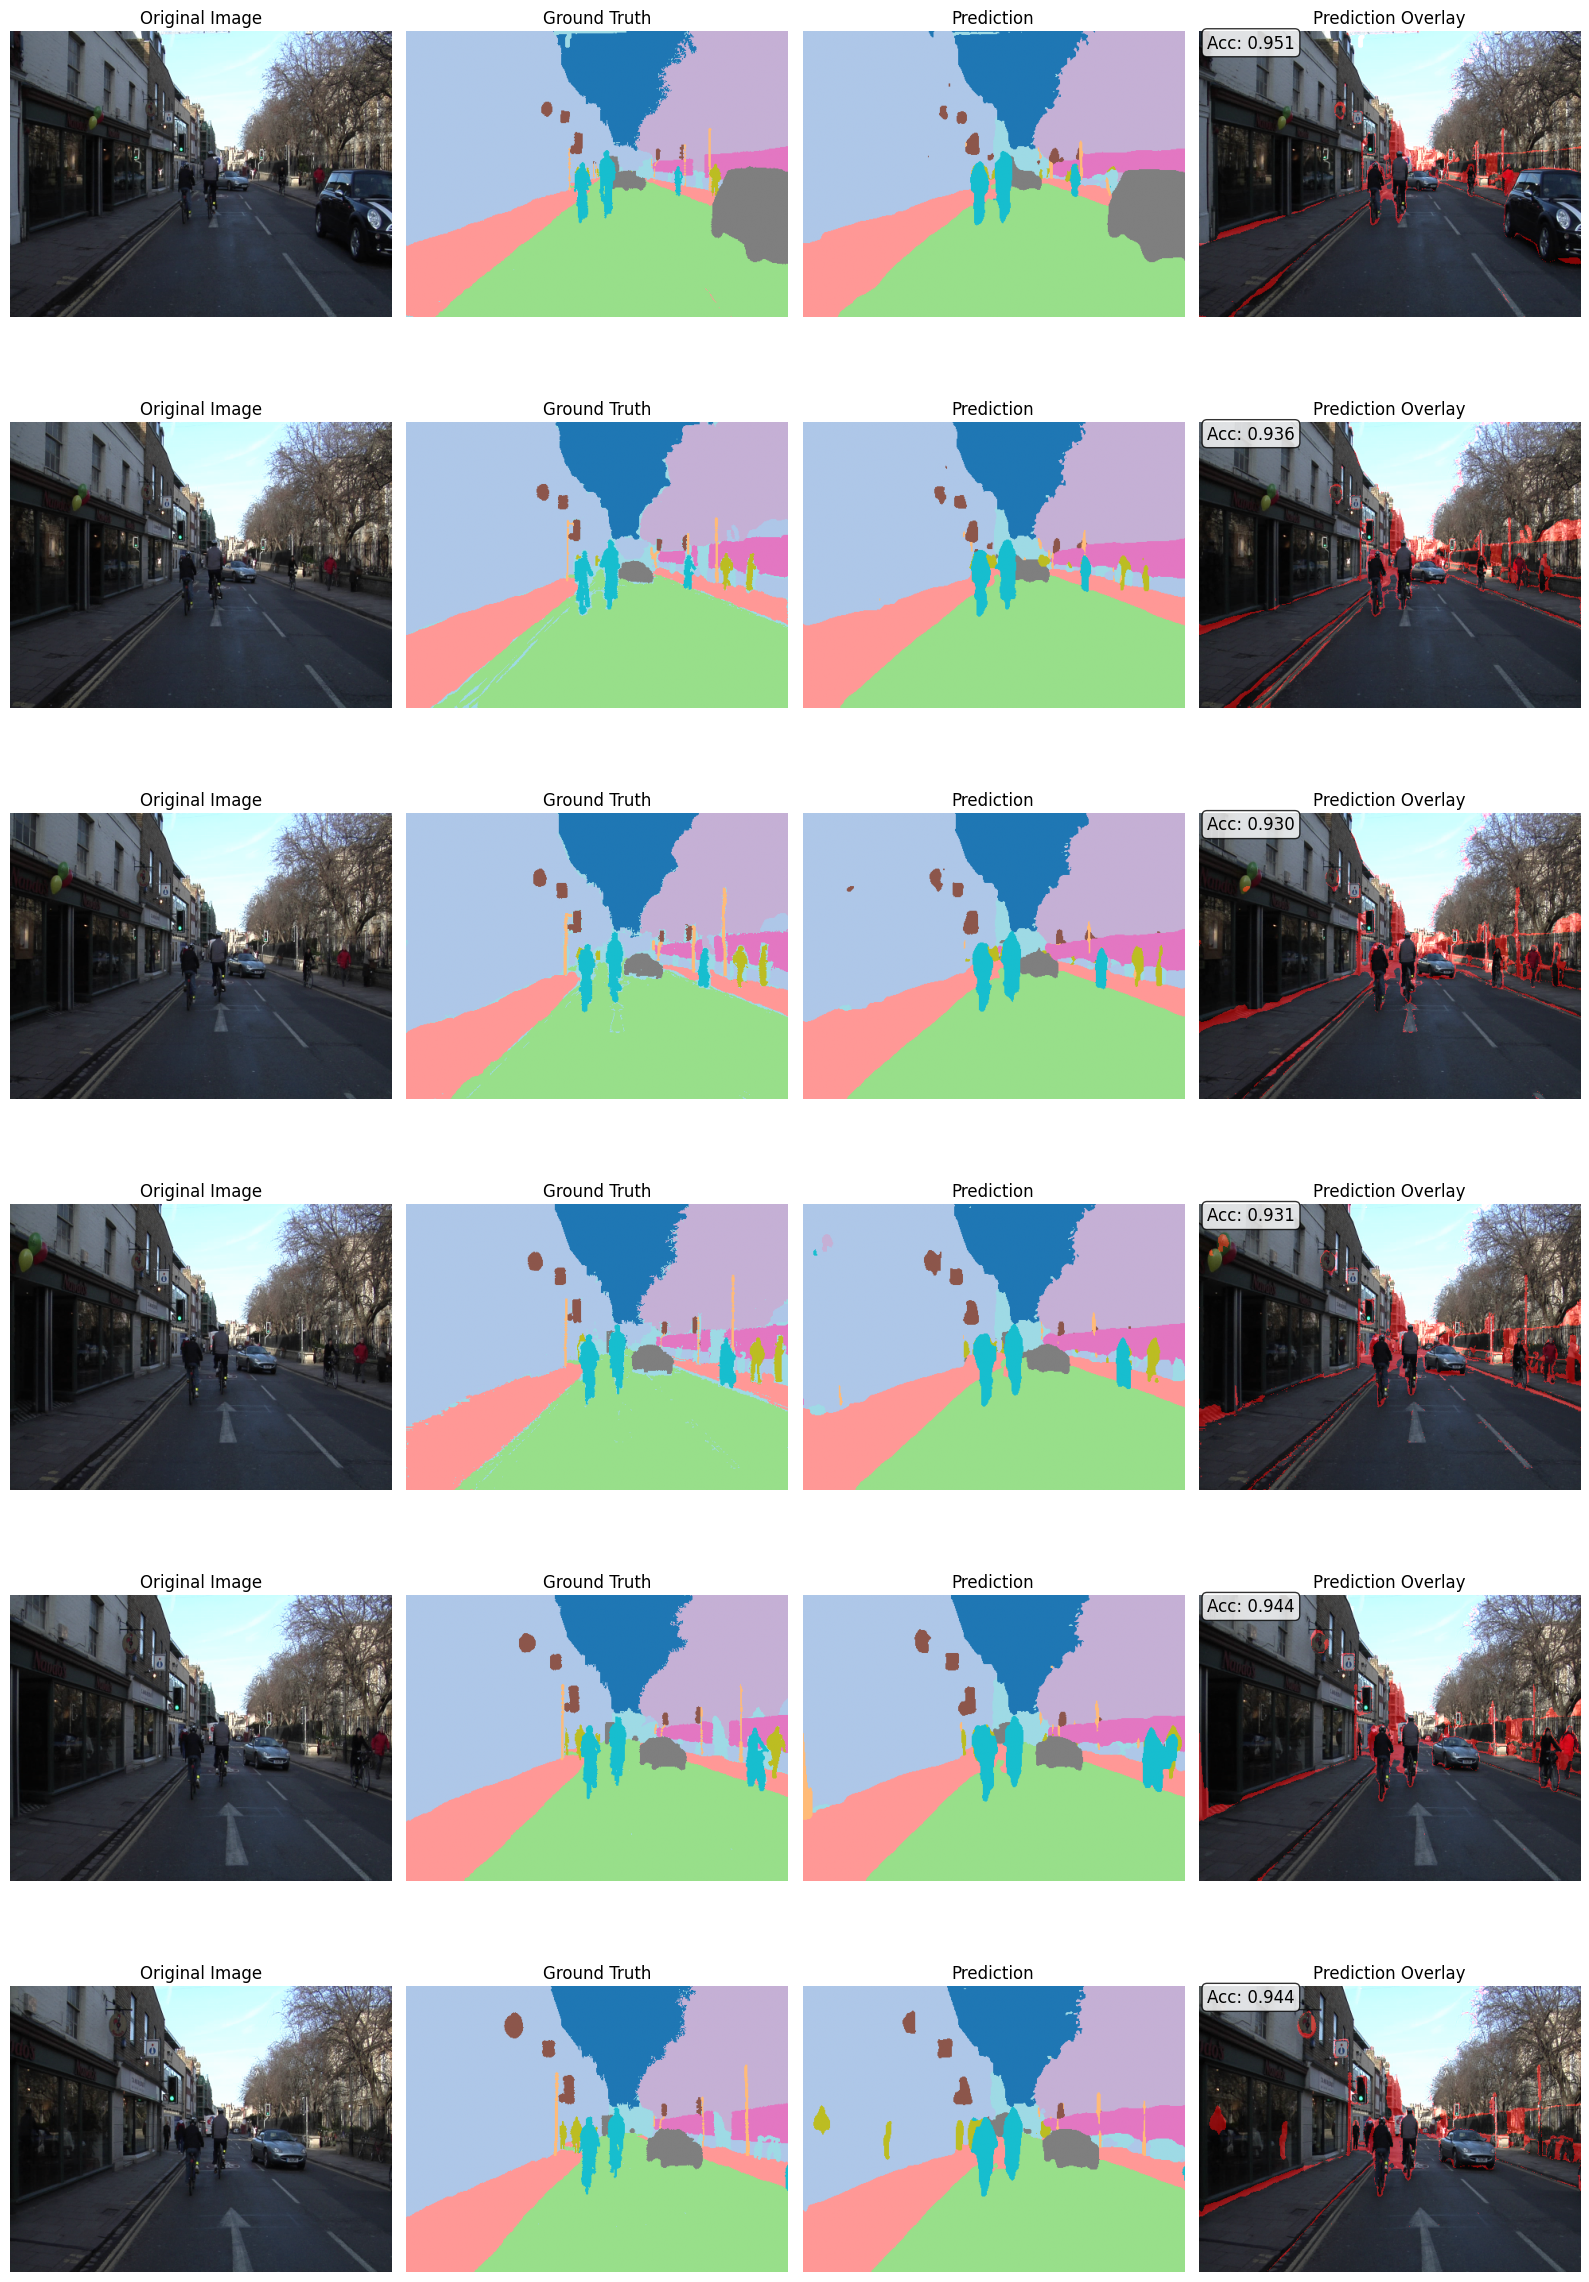

In [ ]:
model_to_val.eval()
device = next(model_to_val.parameters()).device

num_samples = 6
fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))

with torch.no_grad():
    for idx in range(num_samples):
        image, mask = val_dataset[(idx+1)*5]
        image_batch = image.unsqueeze(0).to(device)
        
        logits = unet_module(image_batch)
        pred = torch.argmax(logits, dim=1).cpu().squeeze()
        
        img_np = image.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_np * std + mean
        img_np = np.clip(img_np, 0, 1)
        
        mask_np = mask.numpy()
        pred_np = pred.numpy()
        
        axes[idx, 0].imshow(img_np)
        axes[idx, 0].set_title('Original Image')
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(mask_np, cmap='tab20', vmin=0, vmax=11)
        axes[idx, 1].set_title('Ground Truth')
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(pred_np, cmap='tab20', vmin=0, vmax=11)
        axes[idx, 2].set_title('Prediction')
        axes[idx, 2].axis('off')
        
        error_mask = (pred_np != mask_np)
        overlay = img_np.copy()
        overlay[error_mask, 0] = np.clip(overlay[error_mask, 0] + 0.5, 0, 1)
        
        axes[idx, 3].imshow(overlay)
        axes[idx, 3].set_title('Prediction Overlay')
        axes[idx, 3].axis('off')
        
        correct = (pred_np == mask_np).sum()
        total = mask_np.size
        pixel_acc = correct / total
        axes[idx, 3].text(10, 20, f'Acc: {pixel_acc:.3f}', 
                          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                          fontsize=12, color='black')

plt.tight_layout()
plt.show()
